# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|------|
| Prima Surya Nusantara | 5054251036|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [7]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

sns.set_theme(style="whitegrid")


In [8]:
mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features.copy()
y = mushroom.data.targets.copy()

df = pd.concat([X, y], axis=1)

print("Jumlah baris dan kolom:", df.shape)

display(df.head())

Jumlah baris dan kolom: (8124, 23)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [9]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

print("\nInformasi dataset:")
df.info()

print("\nJumlah '?' pada kolom stalk-root:")
print(df["stalk-root"].eq("?").sum())

df = df.replace("?", np.nan)

print("\nJumlah missing value per kolom:")
print(df.isna().sum())

print("\nTotal missing value:", df.isna().sum().sum())

Jumlah baris: 8124
Jumlah kolom: 23

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring

In [ ]:
jumlah_unik = df[X.columns].nunique()

print("Jumlah nilai unik pada setiap fitur:")
print(jumlah_unik)

print("\nKategori pada veil-type:")
print(df["veil-type"].dropna().unique())

Jumlah nilai unik pada setiap fitur:
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   4
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

Kategori pada veil-type:
['p']


           Jumlah  Persentase (%)
poisonous                        
e            4208            51.8
p            3916            48.2


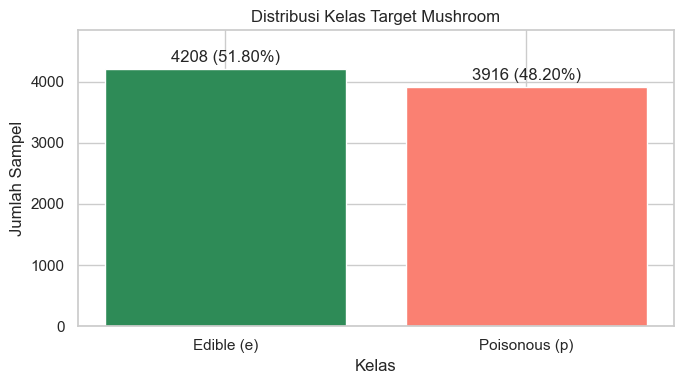

In [14]:
target = y.iloc[:, 0]

jumlah_kelas = target.value_counts().reindex(["e", "p"], fill_value=0)

persentase = jumlah_kelas / jumlah_kelas.sum() * 100

print(pd.DataFrame({
    "Jumlah": jumlah_kelas,
    "Persentase (%)": persentase.round(2)
}))

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    ["Edible (e)", "Poisonous (p)"],
    jumlah_kelas.values,
    color=["seagreen", "salmon"]
)

ax.bar_label(
    bars,
    labels=[
        f"{jumlah} ({persen:.2f}%)"
        for jumlah, persen in zip(jumlah_kelas, persentase)
    ],
    padding=3
)

ax.set_title("Distribusi Kelas Target Mushroom")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah Sampel")
ax.set_ylim(0, jumlah_kelas.max() * 1.15)

plt.tight_layout()
plt.show()

Jumlah baris duplikat: 0

Persentase missing value:


,Missing (%)
stalk-root,30.53


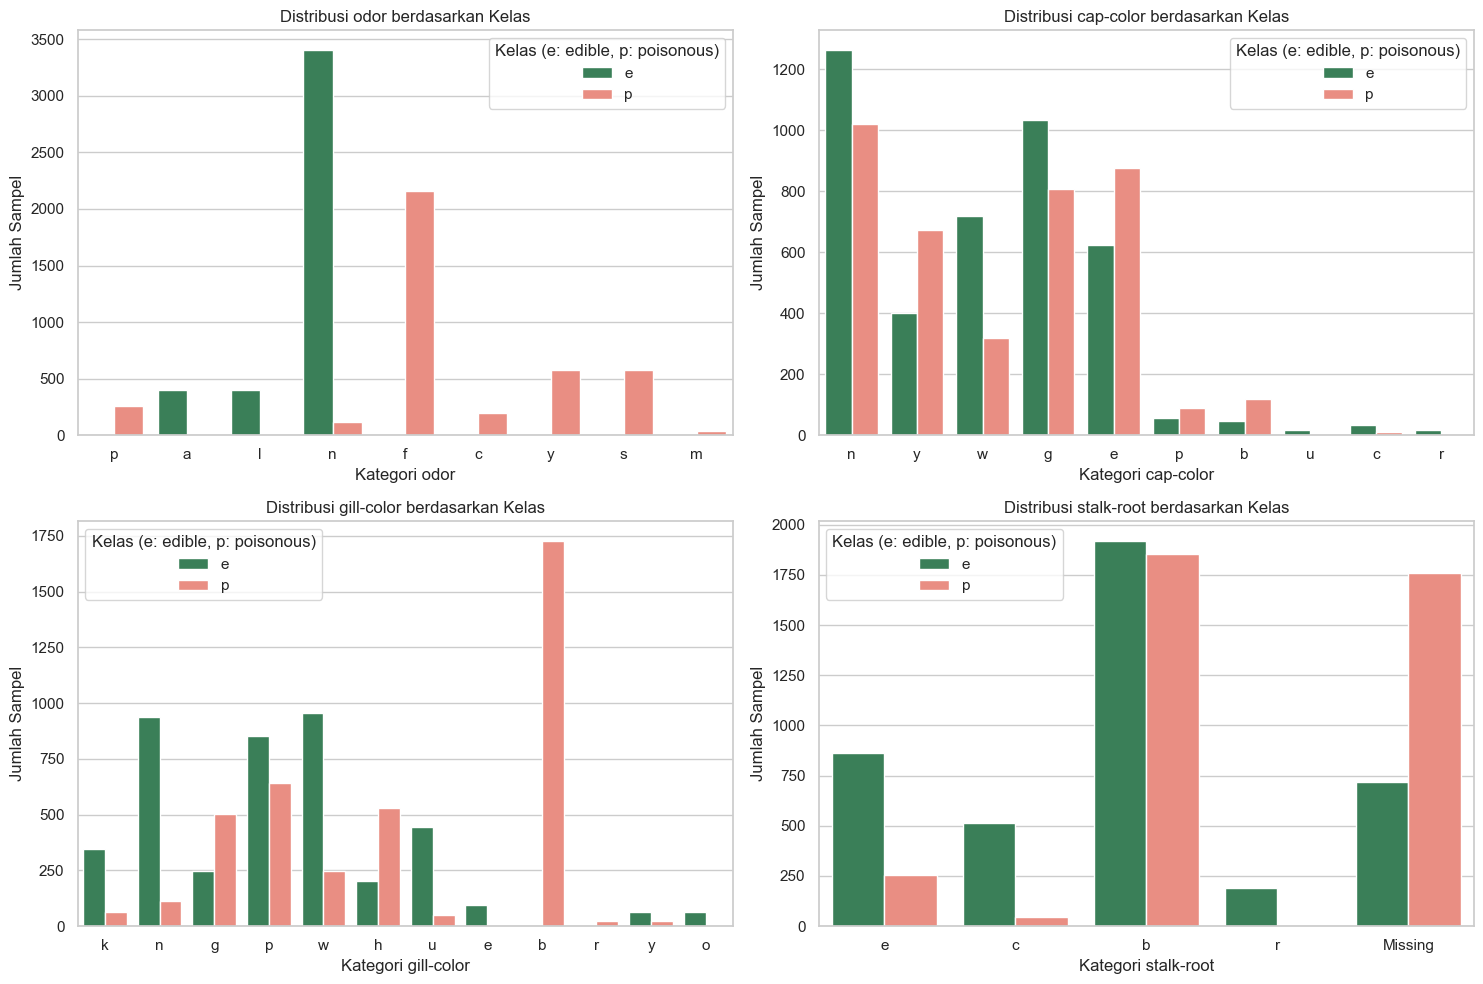


Persentase kelas pada setiap kategori odor:


target,e,p
odor,,
a,100.0,0.0
c,0.0,100.0
f,0.0,100.0
l,100.0,0.0
m,0.0,100.0
n,96.6,3.4
p,0.0,100.0
s,0.0,100.0
y,0.0,100.0



Fitur dengan hanya satu nilai unik:
veil-type    1
dtype: int64


In [ ]:
df_eda = X.copy().replace("?", np.nan)
df_eda["target"] = y.iloc[:, 0]

print("Jumlah baris duplikat:", df_eda.duplicated().sum())

missing = df_eda[X.columns].isna().mean().mul(100)
missing = missing[missing > 0].sort_values(ascending=False)

print("\nPersentase missing value:")
if missing.empty:
    print("Tidak ada missing value.")
else:
    display(missing.round(2).to_frame("Missing (%)"))

fitur_pilihan = ["odor", "cap-color", "gill-color", "stalk-root"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for fitur, ax in zip(fitur_pilihan, axes.flat):
    data_plot = df_eda[[fitur, "target"]].copy()
    data_plot[fitur] = data_plot[fitur].fillna("Missing")

    sns.countplot(
        data=data_plot,
        x=fitur,
        hue="target",
        hue_order=["e", "p"],
        palette={"e": "seagreen", "p": "salmon"},
        ax=ax
    )

    ax.set_title(f"Distribusi {fitur} berdasarkan Kelas")
    ax.set_xlabel(f"Kategori {fitur}")
    ax.set_ylabel("Jumlah Sampel")
    ax.legend(title="Kelas (e: edible, p: poisonous)")

plt.tight_layout()
plt.show()

proporsi_odor = pd.crosstab(
    df_eda["odor"],
    df_eda["target"],
    normalize="index"
).mul(100)

print("\nPersentase kelas pada setiap kategori odor:")
display(proporsi_odor.round(2))

jumlah_unik = df_eda[X.columns].nunique()
print("\nFitur dengan hanya satu nilai unik:")
print(jumlah_unik[jumlah_unik == 1])

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [16]:
df["stalk-root"] = df["stalk-root"].replace("?", np.nan)

print("Missing sebelum penanganan:", df["stalk-root"].isna().sum())

df["stalk-root"] = df["stalk-root"].fillna("Unknown")

print("Missing setelah penanganan:", df["stalk-root"].isna().sum())
print("\nDistribusi stalk-root:")
print(df["stalk-root"].value_counts())

X = df.loc[:, X.columns].copy()

Missing sebelum penanganan: 2480
Missing setelah penanganan: 0

Distribusi stalk-root:
stalk-root
b          3776
Unknown    2480
e          1120
c           556
r           192
Name: count, dtype: int64


In [17]:
jumlah_unik = X.nunique()

fitur_konstan = jumlah_unik[jumlah_unik == 1].index.tolist()
print("Fitur yang dihapus:", fitur_konstan)

X = X.drop(columns=fitur_konstan)
df = df.drop(columns=fitur_konstan)

print("Jumlah fitur setelah penghapusan:", X.shape[1])
print("Fitur yang tersisa:", X.columns.tolist())

Fitur yang dihapus: ['veil-type']
Jumlah fitur setelah penghapusan: 21
Fitur yang tersisa: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [18]:
X = X.copy()

y = mushroom.data.targets.iloc[:, 0].map({"e": 0, "p": 1})

y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

print("\nDistribusi kelas (%):")
display(pd.DataFrame({
    "Train": y_train.value_counts(normalize=True).mul(100),
    "Test": y_test.value_counts(normalize=True).mul(100)
}).rename_axis("Kelas").round(2))

Ukuran X_train: (6499, 21)
Ukuran X_test : (1625, 21)
Ukuran y_train: (6499,)
Ukuran y_test : (1625,)

Distribusi kelas (%):


,Train,Test
Kelas,,
0,51.79,51.82
1,48.21,48.18


In [19]:
from sklearn.preprocessing import OrdinalEncoder

encoder_nb = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.int64
)

X_train_nb = encoder_nb.fit_transform(X_train)
X_test_nb = encoder_nb.transform(X_test)

X_train_nb = X_train_nb + 1
X_test_nb = X_test_nb + 1

min_categories_nb = [
    len(kategori) + 1 for kategori in encoder_nb.categories_
]

print("Ukuran train:", X_train_nb.shape)
print("Ukuran test :", X_test_nb.shape)

display(pd.DataFrame(
    X_train_nb,
    columns=X_train.columns,
    index=X_train.index
).head())

Ukuran train: (6499, 21)
Ukuran test : (1625, 21)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5249,3,4,10,1,3,2,1,1,3,1,...,2,2,7,1,3,2,3,2,6,2
5781,6,3,6,2,6,2,1,1,2,1,...,3,3,3,8,3,3,1,8,2,7
7586,1,3,4,1,6,2,2,1,11,1,...,2,3,8,8,3,3,5,8,4,2
6181,3,3,5,1,8,2,1,2,1,2,...,2,2,7,8,3,2,1,8,5,1
7338,4,4,5,1,3,2,1,2,1,2,...,3,2,7,7,3,2,1,8,5,5


In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder_onehot = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.int64
)

X_train_onehot = encoder_onehot.fit_transform(X_train)

X_test_onehot = encoder_onehot.transform(X_test)

print("Ukuran train:", X_train_onehot.shape)
print("Ukuran test :", X_test_onehot.shape)

display(pd.DataFrame(
    X_train_onehot[:5].toarray(),
    columns=encoder_onehot.get_feature_names_out(),
    index=X_train.index[:5]
))

Ukuran train: (6499, 116)
Ukuran test : (1625, 116)


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
5249,0,0,1,0,0,0,0,0,0,1,...,0,0,1,0,1,0,0,0,0,0
5781,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
7586,1,0,0,0,0,0,0,0,1,0,...,1,0,0,0,1,0,0,0,0,0
6181,0,0,1,0,0,0,0,0,1,0,...,0,1,0,1,0,0,0,0,0,0
7338,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,1,0,0


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [21]:
from sklearn.naive_bayes import CategoricalNB

model_categorical_nb = CategoricalNB(
    alpha=1.0,
    min_categories=min_categories_nb
)

model_categorical_nb.fit(X_train_nb, y_train)

print("Model CategoricalNB berhasil dilatih.")

Model CategoricalNB berhasil dilatih.


In [22]:
y_pred_categorical_nb = model_categorical_nb.predict(X_test_nb)

indeks_kelas_1 = np.where(model_categorical_nb.classes_ == 1)[0][0]
y_proba_categorical_nb = model_categorical_nb.predict_proba(
    X_test_nb
)[:, indeks_kelas_1]

print("Prediksi 5 label pertama:", y_pred_categorical_nb[:5])
print("Probabilitas kelas 1:", y_proba_categorical_nb[:5])

Prediksi 5 label pertama: [1 0 0 1 1]
Probabilitas kelas 1: [1.00000000e+00 3.69123664e-01 1.69343930e-06 1.00000000e+00
 1.00000000e+00]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [23]:
from sklearn.naive_bayes import BernoulliNB

model_bernoulli_nb = BernoulliNB(alpha=1.0)
model_bernoulli_nb.fit(X_train_onehot, y_train)

print("Model BernoulliNB berhasil dilatih.")

Model BernoulliNB berhasil dilatih.


In [24]:
y_pred_bernoulli_nb = model_bernoulli_nb.predict(X_test_onehot)

indeks_kelas_1 = np.where(model_bernoulli_nb.classes_ == 1)[0][0]
y_proba_bernoulli_nb = model_bernoulli_nb.predict_proba(
    X_test_onehot
)[:, indeks_kelas_1]

print("Prediksi 5 label pertama:", y_pred_bernoulli_nb[:5])
print("Probabilitas kelas 1:", y_proba_bernoulli_nb[:5])

Prediksi 5 label pertama: [1 0 0 1 1]
Probabilitas kelas 1: [1.00000000e+00 4.06871535e-01 2.58243564e-09 1.00000000e+00
 1.00000000e+00]


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [25]:
from sklearn.naive_bayes import MultinomialNB

model_multinomial_nb = MultinomialNB(alpha=1.0)
model_multinomial_nb.fit(X_train_onehot, y_train)

print("Model MultinomialNB berhasil dilatih.")

Model MultinomialNB berhasil dilatih.


In [26]:
y_pred_multinomial_nb = model_multinomial_nb.predict(X_test_onehot)

indeks_kelas_1 = np.where(model_multinomial_nb.classes_ == 1)[0][0]
y_proba_multinomial_nb = model_multinomial_nb.predict_proba(
    X_test_onehot
)[:, indeks_kelas_1]

print("Prediksi 5 label pertama:", y_pred_multinomial_nb[:5])
print("Probabilitas kelas 1:", y_proba_multinomial_nb[:5])

Prediksi 5 label pertama: [1 0 0 1 1]
Probabilitas kelas 1: [1.00000000e+00 3.69231017e-01 1.69422011e-06 1.00000000e+00
 1.00000000e+00]


# 4. Evaluasi Model

In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, roc_auc_score
)

prediksi_model = {
    "CategoricalNB": y_pred_categorical_nb,
    "BernoulliNB": y_pred_bernoulli_nb,
    "MultinomialNB": y_pred_multinomial_nb
}

hasil_evaluasi = []

for nama, prediksi in prediksi_model.items():
    hasil_evaluasi.append({
        "Model": nama,
        "Accuracy": accuracy_score(y_test, prediksi),
        "Precision": precision_score(
            y_test, prediksi, pos_label=1, zero_division=0
        ),
        "Recall": recall_score(
            y_test, prediksi, pos_label=1, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, prediksi, pos_label=1, zero_division=0
        )
    })

tabel_evaluasi = pd.DataFrame(hasil_evaluasi).set_index("Model")
display(tabel_evaluasi.round(4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
CategoricalNB,0.9458,0.9901,0.8966,0.9410
BernoulliNB,0.9329,0.9814,0.8774,0.9265
MultinomialNB,0.9458,0.9901,0.8966,0.9410


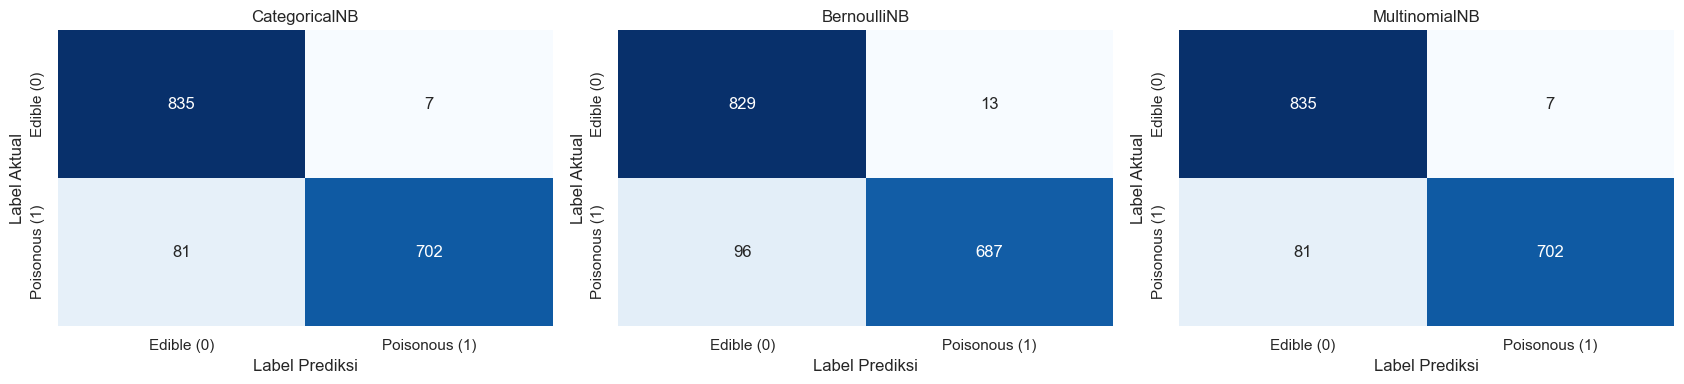

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, (nama, prediksi) in zip(axes, prediksi_model.items()):
    cm = confusion_matrix(y_test, prediksi, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Edible (0)", "Poisonous (1)"],
        yticklabels=["Edible (0)", "Poisonous (1)"],
        ax=ax
    )

    ax.set_title(nama)
    ax.set_xlabel("Label Prediksi")
    ax.set_ylabel("Label Aktual")

plt.tight_layout()
plt.show()

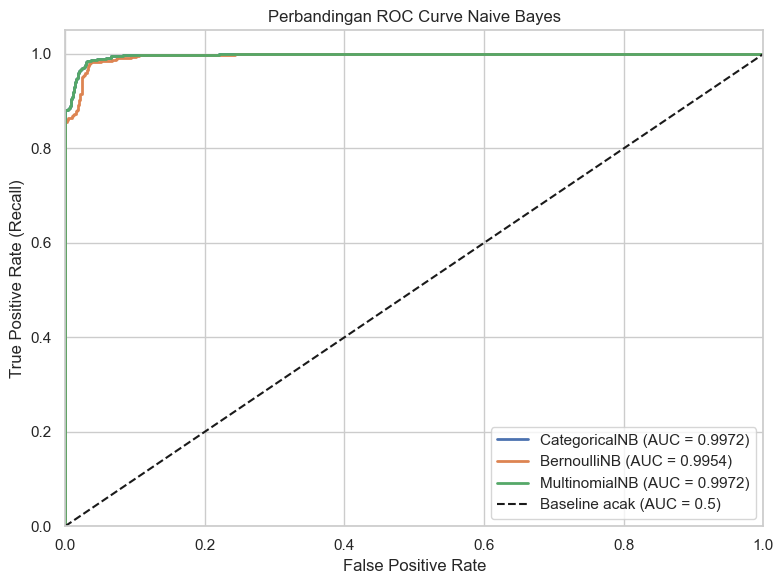

In [29]:
probabilitas_model = {
    "CategoricalNB": y_proba_categorical_nb,
    "BernoulliNB": y_proba_bernoulli_nb,
    "MultinomialNB": y_proba_multinomial_nb
}

fig, ax = plt.subplots(figsize=(8, 6))

for nama, probabilitas in probabilitas_model.items():
    fpr, tpr, _ = roc_curve(y_test, probabilitas, pos_label=1)
    auc = roc_auc_score(y_test, probabilitas)

    ax.plot(fpr, tpr, linewidth=2, label=f"{nama} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", label="Baseline acak (AUC = 0.5)")

ax.set_title("Perbandingan ROC Curve Naive Bayes")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 5. Analisis

## 1. Perbandingan performa model
Eksperimen membandingkan CategoricalNB, BernoulliNB, dan MultinomialNB menggunakan pembagian data train dan test sebesar 80:20 dengan stratifikasi kelas. Data test terdiri dari 1.625 sampel, yaitu 842 jamur edible dan 783 jamur poisonous. Kelas poisonous ditetapkan sebagai kelas positif (1).

| Model         | Accuracy | Precision | Recall | F1-Score |      AUC |
| ------------- | -------: | --------: | -----: | -------: | -------: |
| CategoricalNB |   94,58% |    99,01% | 89,66% |   94,10% | 0,997185 |
| BernoulliNB   |   93,29% |    98,14% | 87,74% |   92,65% | 0,995428 |
| MultinomialNB |   94,58% |    99,01% | 89,66% |   94,10% | 0,997185 |

CategoricalNB dan MultinomialNB memperoleh hasil evaluasi yang sama dan lebih tinggi daripada BernoulliNB pada seluruh metrik yang ditampilkan. Keduanya mengklasifikasikan 1.537 sampel dengan benar, sedangkan BernoulliNB mengklasifikasikan 1.516 sampel dengan benar. Selisih akurasi keduanya terhadap BernoulliNB adalah sekitar 1,29 poin persentase.

Precision CategoricalNB dan MultinomialNB sebesar 99,01% menunjukkan bahwa hampir seluruh sampel yang diprediksi poisonous memang beracun. Namun, recall sebesar 89,66% berarti masih ada sekitar 10,34% jamur beracun yang tidak berhasil terdeteksi.

BernoulliNB menghasilkan precision sebesar 98,14% dan recall sebesar 87,74%. Dengan demikian, model ini sedikit lebih sering memberikan peringatan beracun yang keliru sekaligus melewatkan lebih banyak jamur beracun. F1-Score yang lebih rendah juga menunjukkan keseimbangan precision dan recall yang lebih rendah pada eksperimen ini.

## 2. Analisis Confusion Matrix
| Model         | TN: edible → edible | FP: edible → poisonous | FN: poisonous → edible | TP: poisonous → poisonous |
| ------------- | ------------------: | ---------------------: | ---------------------: | ------------------------: |
| CategoricalNB |                 835 |                      7 |                     81 |                       702 |
| BernoulliNB   |                 829 |                     13 |                     96 |                       687 |
| MultinomialNB |                 835 |                      7 |                     81 |                       702 |

CategoricalNB dan MultinomialNB menghasilkan 88 kesalahan, sedangkan BernoulliNB menghasilkan 109 kesalahan. Dibandingkan kedua model lainnya, BernoulliNB menghasilkan tambahan 6 false positive dan 15 false negative.

Kesalahan yang paling penting dalam konteks ini adalah false negative, yaitu jamur beracun diprediksi sebagai edible. CategoricalNB dan MultinomialNB masih menghasilkan 81 kesalahan jenis ini, sedangkan BernoulliNB menghasilkan 96. Oleh karena itu, akurasi yang tinggi belum cukup untuk menyatakan bahwa model dapat digunakan sebagai penentu keamanan konsumsi jamur.

## 3. Analisis ROC dan AUC
Seluruh model memiliki AUC mendekati 1, yang menunjukkan kemampuan sangat baik dalam mengurutkan sampel poisonous lebih tinggi daripada edible berdasarkan skor probabilitasnya. CategoricalNB dan MultinomialNB memperoleh AUC 0,997185, sedikit lebih tinggi daripada BernoulliNB sebesar 0,995428.

AUC yang tinggi tidak bertentangan dengan keberadaan false negative. ROC-AUC menilai pemisahan kelas pada berbagai threshold, sedangkan confusion matrix berasal dari satu aturan keputusan prediksi. Dengan demikian, model dapat memiliki pemisahan skor yang sangat baik tetapi tetap melewatkan sejumlah jamur beracun pada keputusan bawaan. AUC juga tidak menunjukkan bahwa nilai probabilitas model sudah terkalibrasi dengan baik.

# 6. Kesimpulan dan Saran

## 6.1. Kesimpulan
CategoricalNB dan MultinomialNB memberikan hasil terbaik pada pembagian data yang digunakan, dengan akurasi 94,58%, precision 99,01%, recall 89,66%, F1-Score 94,10%, dan AUC 0,997185. BernoulliNB menghasilkan performa sedikit lebih rendah pada seluruh metrik.

Hasil eksperimen menunjukkan bahwa cara merepresentasikan kategori dan cara model memperhitungkan kemunculan serta ketidakhadiran kategori berkaitan dengan perbedaan prediksi. Meskipun demikian, keunggulan yang diamati masih terbatas pada satu pembagian train-test.

Seluruh model masih menghasilkan false negative. Oleh karena itu, model ini merupakan hasil eksperimen klasifikasi dan belum layak dijadikan acuan untuk menentukan keamanan konsumsi jamur.

## 6.2. Saran
1. Evaluasi threshold prediksi. Menurunkan threshold kelas poisonous berpotensi meningkatkan recall dan mengurangi false negative, dengan konsekuensi peningkatan false positive. Pemilihan threshold harus dilakukan menggunakan data validasi, bukan test set.
2. Lakukan tuning parameter alpha. Uji beberapa nilai smoothing menggunakan cross-validation untuk mengetahui pengaruhnya terhadap recall, F1-Score, dan AUC.
3. Gunakan Stratified Cross-Validation. Bandingkan rata-rata dan variasi metrik antarfold agar kesimpulan tidak bergantung pada satu pembagian data. Encoder harus di-fit hanya pada bagian train setiap fold.
4. Bandingkan strategi missing value. Uji kategori "Unknown" dengan imputasi modus yang dipelajari dari data train untuk melihat pengaruhnya terhadap performa.
5. Tambahkan model pembanding, seperti Logistic Regression atau Random Forest, untuk menguji apakah pendekatan lain memberikan hasil lebih baik. Test set tetap digunakan hanya untuk evaluasi akhir setelah pemilihan model dan parameter selesai.